# Methods and decisions

**This notebook explains method selection and validation. The subsequent held-out evaluation is complete in [Final results](04_final_results.ipynb).**

Read this after the data audit. The question is whether a learned local representation helps reconstruct energy and position, and whether masked pretraining helps those two tasks. The [decision trail](../docs/decisions.md) explains the choices; the [confirmation report](../reports/confirmation/README.md) gives the verified results.


## 1. From the whole calorimeter to one measured window

The original event is a **30 x 85** grid. Find its largest **measured** crystal, then keep the surrounding **7 x 7** window. The true impact point never chooses the window.

```text
30 x 85 measured crystals -> observed maximum -> 7 x 7 window + validity mask
                                                  |
                                energy and a local position offset
                                                  |
                           add the known window origin to the position
```

The local window retains a median 99.52% of clean deposited energy in the exploratory study. Under noise it can select the wrong maximum, especially near 1 GeV. Those events remain in the evaluation. Fixed array indices are not certified physical cell centers.


## 2. Measurement conditions

| Condition | What enters the model | Role |
| --- | --- | --- |
| Provided deposits | No added measurement fluctuations | Control |
| Noise | Signed Gaussian readout fluctuations | Control |
| Noise + cut | Same fluctuations; cell values below 50 MeV set to zero | Main condition |

All methods see the same measurements. The cut acts on crystals, not on the incident photon energy. It also removes real small deposits; noise is not an extra physical energy deposited by the photon. See the [physical motivation](../docs/decisions.md#physical-interpretation).


## 3. Direct specialists and matched references

CNN and Transformer receive deposits, validity and geometric indices. The Transformer uses **49 crystal tokens**, each embedded to width 64. This differs from the earlier full-grid model with 102 patches. Both networks estimate energy directly and position relative to the observed anchor, without a calibrated reference as input.

- Energy: one specialist, relative Huber loss with a fixed 10% transition.
- Position: another specialist, coordinate Huber loss with a one-unit transition.
- References: affine energy, quadratic energy, periodic barycenter position.

Dividing the *training residual* by true energy defines the energy loss. It does not put true energy into the model input. Separate tasks help position strongly in our comparison; their loss weights also changed, so this is not a pure task-interference test.


## 4. Exploratory evidence behind the choices

This historical figure uses one training seed and 5,947 validation events. Lower is better. The hatched energy reference was repaired after that run by removing excessive regularization. Its train-only specification was then fixed before the three-seed confirmation below.


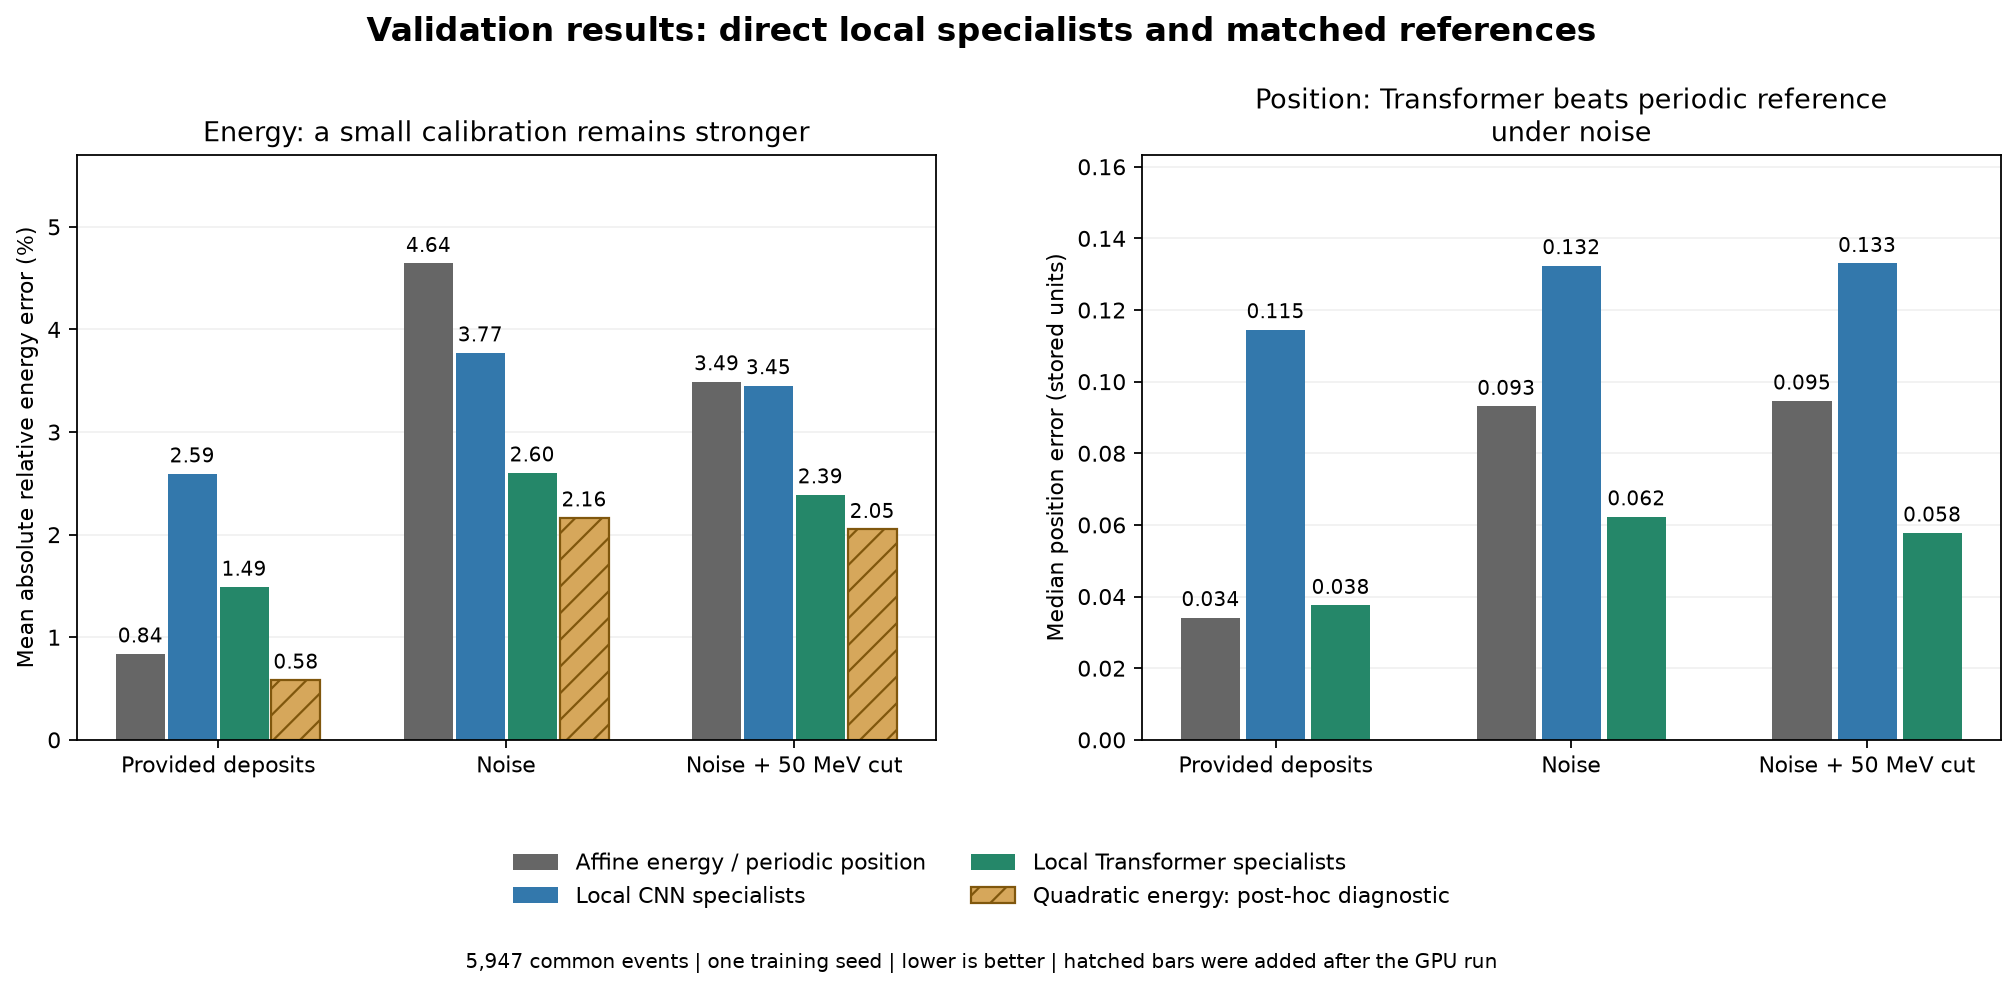

In [1]:
from pathlib import Path

from IPython.display import Image, display

project = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "configs/confirmation.json").exists()
)
display(
    Image(filename=str(project / "reports/experiments/methodology_review/decision_overview.png"))
)

These exploratory results motivated the local methodology: learned spatial patterns helped noisy position, while the repaired quadratic energy reference remained strong. They guided the protocol; the three-seed confirmation below is the next comparison.


## 5. One shared pretraining, then two adaptations

```text
Train windows with hidden measured cells
                   |
        shared Transformer encoder
                   |
      temporary reconstruction decoder
                   |
  discard decoder; copy the same encoder
                   |
          +--------+--------+
          |                 |
   energy fine-tuning  position fine-tuning
          |                 |
     photon energy     impact position
```

Pretraining reconstructs measured deposits, not clean truth behind the noise. Masked cells, measured zeros and edge padding are distinguished. Train only determines the mask-rate diagnostic; no validation targets select the pretrained checkpoint.

For each of three training seeds, one encoder is pretrained once and copied for two separate full-encoder fine-tunings. This is one shared initialization per seed, not two task-specific pretrainings. The resulting specialist weights can differ.


## 6. Confirmation: what improved, and at what cost?

Main condition: **noise + 50 MeV cell cut**, evaluated on the same 5,947 validation events. The neural values below are means of three training-seed scores, **not an ensemble**.

| Metric, lower is better | Direct Transformer | Pretrained Transformer | Stronger matched reference |
| --- | ---: | ---: | ---: |
| Energy mean absolute relative error | 2.424% | 2.150% | 2.051%, quadratic |
| Median position error, stored index units | 0.07076 | 0.04704 | 0.09460, periodic |

- **Position:** fine-tuning improves all three seeds; its mean score is about 50% below
the periodic reference. The extra validation-noise draws preserve this advantage.
- **Energy:** pretraining helps on average, but does not consistently beat the quadratic
reference. The first seed is almost tied with direct training.
- **Cost:** counting the shared pretraining once, the two fine-tuned specialists cost
about **75-80% more active training and validation time** than the two direct Transformers.
- **Failure mode:** all **10/5,947** large position failures on the primary noise draw remain.
A wrong observed maximum can place the local window far from a low-energy shower.

This confirms a useful local position result, not a universal foundation model or a validated detector response. These validation events have also guided earlier choices; the held-out test and current-checkpoint Docker comparison are now completed in [Final results](04_final_results.ipynb). This section preserves the validation evidence.

Read the [confirmation report](../reports/confirmation/README.md) for seed ranges, tails, noise repeats and cost, and the [fixed protocol](../docs/methodology.md) for exact settings. The execution wrappers are [Colab](03_colab_confirmation.ipynb) and [Kaggle](runners/kaggle_confirmation.ipynb).


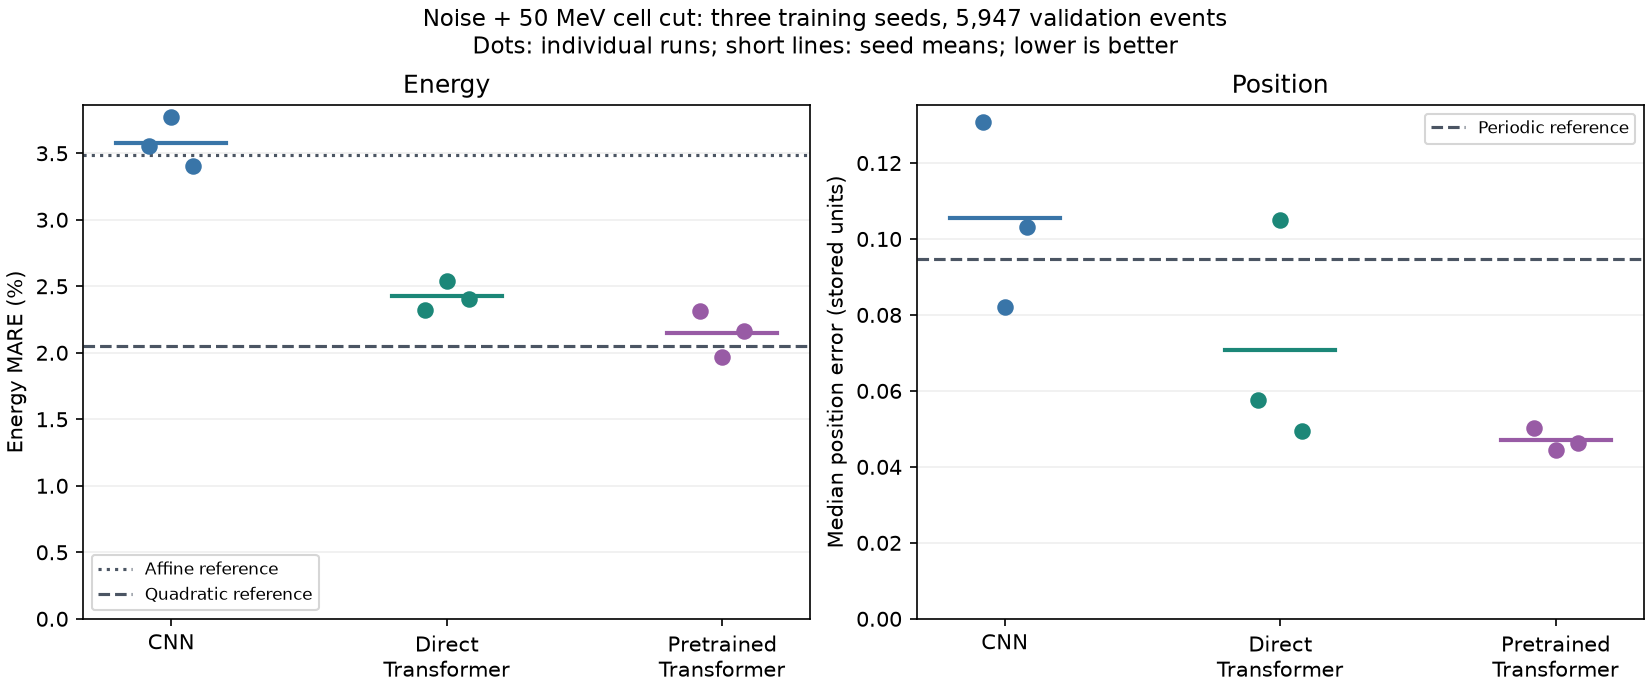

In [2]:
display(Image(filename=str(project / "reports/confirmation/accuracy.png")))
